# Motion-Corrected Image Reconstruction (MCIR)


In [1]:
__version__ = '0.2.0'

# import engine module
import sirf.Gadgetron as pMR
from sirf.Utilities import examples_data_path
# from sirf_exercises import exercises_data_pathtoken
import sirf.Reg as pReg


from cil.framework import  AcquisitionGeometry, BlockDataContainer, BlockGeometry
from cil.optimisation.functions import Function, OperatorCompositionFunction, SmoothMixedL21Norm, L1Norm, L2NormSquared, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares, ZeroFunction
from cil.optimisation.operators import GradientOperator, BlockOperator, ZeroOperator, CompositionOperator,LinearOperator
from cil.optimisation.algorithms import PDHG, FISTA, GD, SPDHG
from cil.plugins.ccpi_regularisation.functions import FGP_TV

# import further modules
import os
import numpy as np
import scipy.signal as sp_signal

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import functools
import cil
import sirf

assert cil.version.version == '23.1.0'
print (sirf.__version__)
assert sirf.__version__ == '3.6.0'

3.6.0


In [2]:
# Plotting function
data_path = '/home/jovyan/work/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple, save_itrobj
print ("Ciao")


Ciao


In [3]:
import importlib
importlib.reload(utils)
from utils import plot_rpe_3d, plot_rpe_3d_simple, saveCallback, add_HORIZONTAL_phase_shift

In [4]:
############# SETUP #################
# number of motion states
Nms = 3
# max
max_shift = 20.
# setup linear shifts
shifts = np.linspace(0, 1, Nms) * max_shift

## Recon parameters
n_epochs = 100
# factor in front of L2Norm
omega = 0.5
# regularisation parameter
alpha = 2e-5

recons = 'recons_ignore-acq_4bis'

In [5]:
# data_path = exercises_data_path('MR')

filename = os.path.join(data_path, '3D_GRPE_no_motion.h5')

In [6]:
# Load in the data
acq_data = pMR.AcquisitionData(filename)
acq_data.sort_by_time()

reading from /home/jovyan/work/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from /home/jovyan/work/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5
0%..10%..20%..31%..40%..50%..61%..70%..80%..90%..
Finished reading acquisitions from /home/jovyan/work/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5


In [7]:
csm = pMR.CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data) 

E = pMR.AcquisitionModel(acqs=acq_data, imgs=csm)
E.set_coil_sensitivity_maps(csm)


# Adding horizontal phase shift

## Create Motion States

In [8]:
import importlib
importlib.reload(utils)

from utils import split_data_with_horizontal_shifts, create_AcquisitionModel_for_each_motion_state 

acq_ms = split_data_with_horizontal_shifts(acq_data, shifts)

E_ms = create_AcquisitionModel_for_each_motion_state(acq_ms, csm)




In [9]:
import functools
im_fista_ms = [0] * Nms

im_ms = E_ms[0].inverse(acq_ms[0])

for ind in range(Nms):

    # Starting image
    x_init = im_ms.clone()
    # x_init.fill(0.0)

    # Objective function
    f = LeastSquares(E_ms[ind], acq_ms[ind], c=1)
    G = ZeroFunction()

    # Set up FISTA for least squares
    fista = FISTA(initial=x_init, f=f, g=G)
    fista.max_iteration = 100
    fista.update_objective_interval = 5

    # Run FISTA
    sc = functools.partial(saveCallback, fista, f"FISTA_L2_ms_{ind}", os.path.join(data_path, recons, f'MS_{Nms}'))
    fista.run(20, verbose=1, callback=sc)
    
    # Get result
    im_fista_ms[ind] = fista.get_output()

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          1.09874e-02
        5        100         6.805          7.83930e-04
       10        100         6.793          1.10394e-04
       15        100         6.732          6.42716e-05
       20        100         6.701          5.53420e-05
-------------------------------------------------------
       20        100         6.701          5.53420e-05
Stop criterion has been reached.

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          1.08933e-02
        5        100         6.548          7.30869e-04
       10        100         6.615          1.81212e-04
       15        100         6.590          1.39060e-04
       20        100         6.557          1.28848e-04
-------------------------------------------------------
       20     

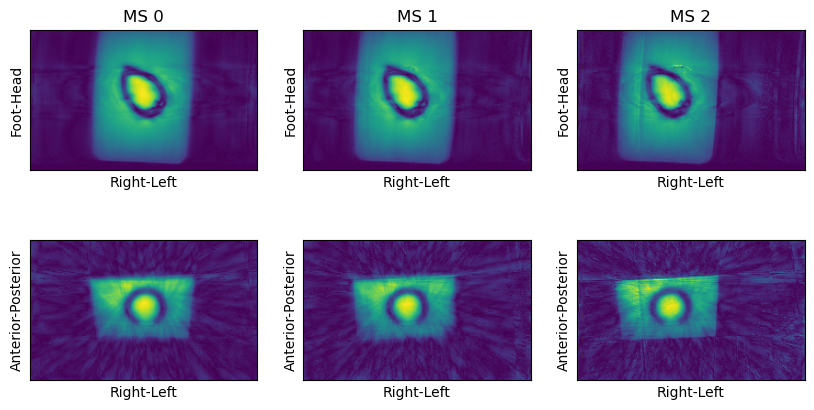

In [10]:
# Prepare results
#%matplotlib inline
im_fista_ms_arr = []
im_fista_diff_arr = []
for ind in range(Nms):
    im_fista_ms_arr.append(im_fista_ms[ind].as_array())
    im_fista_diff_arr.append(np.abs(im_fista_ms[ind].as_array()) - np.abs(im_fista_ms_arr[0]))
    
# Visualise different motion states
plot_rpe_3d_simple(im_fista_ms_arr[:], [64, 64], [ f'MS {ms}' for ms in range(Nms) ], fig_name="motion_state_example")
print('\n')
# Visualise difference to first motion state
# plot_rpe_3d_simple(im_fista_diff_arr[:], [64, 64], [f'MS {ms}- MS 0'  for ms in range(Nms) ])

## Create Motion Vector fields from known shifts

In [11]:
class NiftyResampleWithNormCache(pReg.NiftyResample):

    def __init__(self, *args, **kwargs):
        self._norm = None
        super().__init__(*args, **kwargs)
        
    def norm(self):
        if self._norm is not None:
            return self._norm
        self._norm = self.calculate_norm()
        return self._norm

    def calculate_norm(self):
        return LinearOperator.PowerMethod(self, method='composed_with_adjoint')

# Motion fransformation object
mf_resampler = [0] * Nms

# Forward transformation (i.e. reference image transformed to current motion state)
im_forward = [0] * Nms

# Backward transformation (i.e. current motion image transformed to reference motion state)
im_backward = [0] * Nms

tms = []
import logging

for shift in shifts:
    # fix the pixel spacing
    spacing = im_fista_ms[0].get_geometrical_info().get_spacing()
    # There is inconsistency in SIRF wrt to the order of the dimensions
    # here we rely on the fact that the spacing is uniform.
    uniform = (spacing[0] == spacing[1]) and (spacing[1] == spacing[2]) and (spacing[0] == spacing[2])
    if not uniform:
        logging.warn('The spacing is not uniform. The results might be incorrect.')
    t_x=shift * spacing[0]
    t_y=0
    tm = pReg.AffineTransformation(np.array(\
            [[1, 0, 0, t_x], \
             [0, 1, 0, t_y], \
             [0, 0, 1, 0  ], \
             [0, 0, 0, 1  ]]))
    tms.append(tm)
    
for ind in range(Nms):

    # Create resampler
    mf_resampler[ind] = NiftyResampleWithNormCache()
    # check units used by the resampler
    mf_resampler[ind].set_reference_image(im_fista_ms[0])
    mf_resampler[ind].set_floating_image(im_fista_ms[ind])
    mf_resampler[ind].add_transformation(tms[ind])
    mf_resampler[ind].set_padding_value(0)
    mf_resampler[ind].set_interpolation_type_to_linear()

    im_forward[ind] = mf_resampler[ind].forward(im_fista_ms[0])
    im_backward[ind] = mf_resampler[ind].backward(im_fista_ms[ind])

## Let's look at the backward transformed images (i.e. the images transformed to the reference motion state).

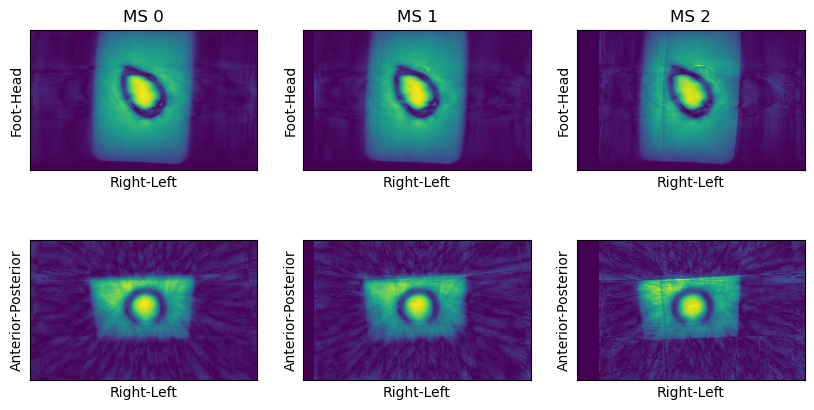

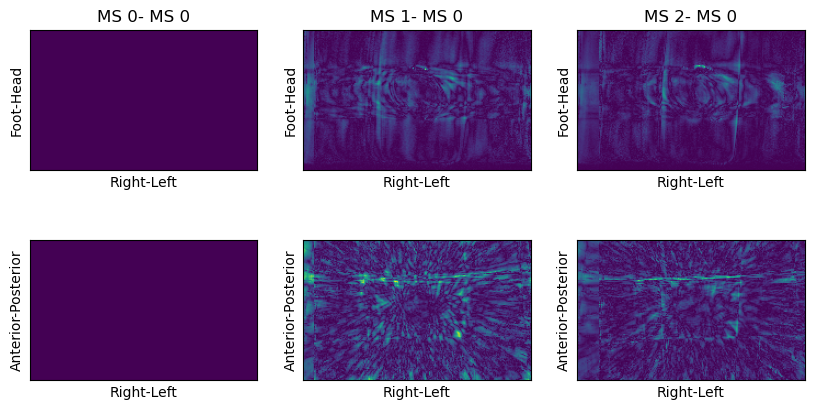

In [12]:
# Prepare results
%matplotlib inline
im_backward_arr = []
im_backward_diff_arr = []
for ind in range(Nms):
    im_backward_arr.append(im_backward[ind].as_array())
    im_backward_diff_arr.append(np.abs(im_backward[ind].as_array()) - np.abs(im_backward[0].as_array()))
    
# Visualise different motion states transformed to reference motion state
plot_rpe_3d_simple(im_backward_arr, [64, 64], [ f'MS {ms}' for ms in range(Nms) ])

# Visualise difference to first motion state
plot_rpe_3d_simple(im_backward_diff_arr, [64, 64], [f'MS {ms}- MS 0'  for ms in range(Nms) ])


## Modifications to CIL/SIRF (check comments to see whether cell(s) can be removed)

In [13]:
# this cell is to be removed if using newer CIL version that implements 1470 (leave default, symmetric=False)

# Overriding PowerMethod to ensure no bug
class MyLinearOperator(LinearOperator):
    
    def PowerMethod(operator, max_iteration=10, initial=None, tolerance = 1e-5,  return_all=False):

        symmetric = False
        try:
            if operator.domain_geometry()==operator.range_geometry():
                symmetric = True
        except AssertionError:
            pass

        if initial is None:
            x0 = operator.domain_geometry().allocate('random')
        else:
            x0 = initial.copy()

        y_tmp = operator.range_geometry().allocate()
  
        # Normalize first eigenvector
        x0_norm = x0.norm()
        x0 /= x0_norm
        
        # initial guess for dominant eigenvalue
        eig_old = 1.
        eig_list = []
        diff = np.finfo('d').max
        
        i=0
        while (i < max_iteration and diff > tolerance):
            i+=1
            operator.direct(x0, out = y_tmp)            
            operator.adjoint(y_tmp,out=x0)
            
            # Get eigenvalue using Rayleigh quotient: denominator=1, due to normalization
            x0_norm = x0.norm()      
            x0 /= x0_norm

            eig_new =  np.abs(x0_norm)
            if not symmetric:
                eig_new = np.sqrt(eig_new)

            eig_list.append(eig_new)
            eig_old = eig_new      
        
        if return_all:
            return eig_new, i, x0, eig_list
        else:
            return eig_new
        
    def calculate_norm(self):
        
        r""" Returns the norm of the LinearOperator calculated by the PowerMethod with default values.
                """
        return MyLinearOperator.PowerMethod(self)            


In [14]:
# this cell is to be removed if using newer SIRF version that implements 1182
from packaging import version as pversion
if pversion.parse(sirf.__version__) < pversion.parse('3.7.0'): 
    def NiftyResampler_norm(x):
        out = LinearOperator.PowerMethod(x)
        return out

    setattr(pReg.NiftyResampler, 'norm', NiftyResampler_norm)

In [15]:
# this cell is to be removed if using newer CIL version that implements 1472

if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    def CompositionOperator_norm(comp_operator):
        out = 1.
        for factor in comp_operator.operators:
            out = out * factor.norm()
        return out

    setattr(CompositionOperator, 'norm', CompositionOperator_norm)

In [16]:
# this cell is to be removed if using newer CIL version that implements 1479


import types   # import needed for later
if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    # Overriding proximal, to remove call to function "check_input"
    def new_proximal(self, x, tau, out=None):
        arr = x.as_array()
        if np.iscomplexobj(arr):
            # do real and imag part indep
            in_arr = np.asarray(arr.real, dtype=np.float32, order='C')
            res, info = self.proximal_numpy(in_arr, tau)
            arr.real = res[:]
            in_arr = np.asarray(arr.imag, dtype=np.float32, order='C')
            res, info = self.proximal_numpy(in_arr, tau)
            arr.imag = res[:]
            self.info = info
            if out is not None:
                out.fill(arr)
            else:
                out = x.copy()
                out.fill(arr)
                return out
        else:
            arr = np.asarray(x.as_array(), dtype=np.float32, order='C')
            res, info = self.proximal_numpy(arr, tau)
            self.info = info
            if out is not None:
                out.fill(res)
            else:
                out = x.copy()
                out.fill(res)
                return out

## MCIR with PDHG

In [17]:
from datetime import datetime

In [18]:
C = [CompositionOperator(am, res) for am, res in zip(*(E_ms, mf_resampler))]
A = BlockOperator(*C)

acq_ms_block = BlockDataContainer(*acq_ms)
# x_init = A.adjoint(acq_ms_block)
# x_init.fill(0.0)

F_all_subs = []
for i in acq_ms:
    F_all_subs.append(omega*L2NormSquared(b=i))
    
F = BlockFunction(*F_all_subs)

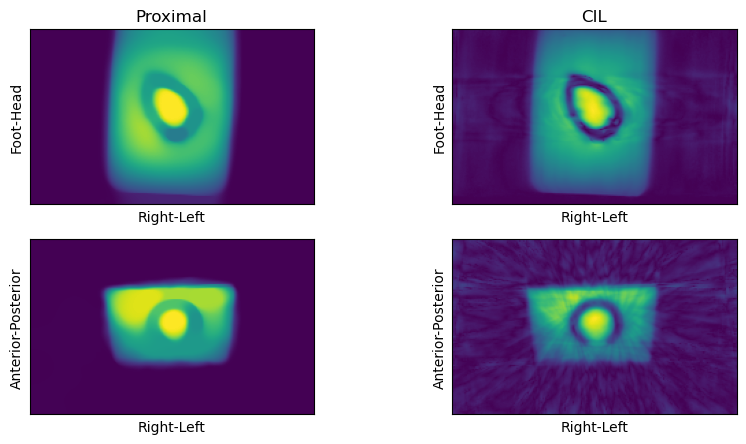

In [19]:
G = alpha * FGP_TV(max_iteration=1000, device='gpu', nonnegativity=False)

if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    # this line is to be removed if using newer CIL version that implements 1479
    G.proximal = types.MethodType(new_proximal, G)
    print("proximal updated")

nn = G.proximal(im_fista_ms[0], tau=1.0)
from cil.optimisation.functions import TotalVariation

G2 = alpha * TotalVariation(max_iteration=2, warm_start=True) 

nn2 = G2.proximal(im_fista_ms[0], tau=1.0)
plot_rpe_3d_simple([nn.as_array(), nn2.as_array()], [64, 64]*2, ['Proximal','CIL'])




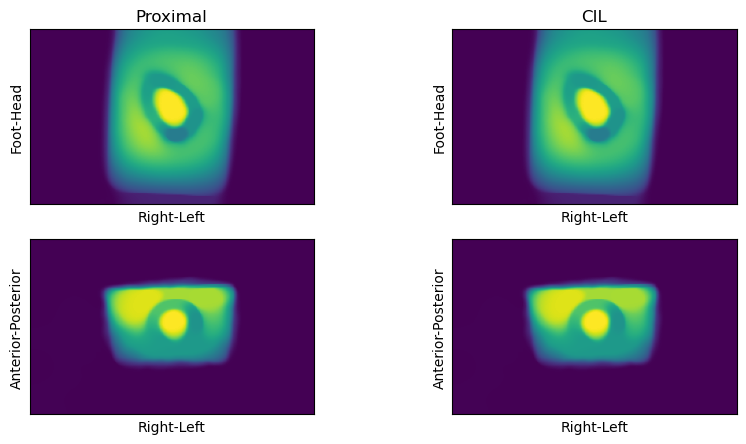

In [20]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.ERROR)
nn2 = G.proximal(im_fista_ms[0], tau=1.0)
plot_rpe_3d_simple([nn.as_array(), nn2.as_array()], [64, 64]*2, ['Proximal','CIL'])

In [21]:

pdhg_2 = PDHG(
            f=F, g=G, operator=A,
            max_iteration=n_epochs,
            update_objective_interval=1)


In [22]:
pdhg_2.run(5, verbose=2, callback=sc)

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap


/opt/conda/lib/python3.10/site-packages/cil/plugins/ccpi_regularisation/functions/regularisers.py:123: ComplexWarning: Casting complex values to real discards the imaginary part
  in_arr = np.asarray(x.as_array(), dtype=np.float32, order='C')


        0        100         0.000    1.69328e-02  -0.00000e+00    1.69328e-02
        1        100        37.686    5.82580e-03 8.48480e-04-9.41021e-13j4.97732e-03+9.41021e-13j
        2        100        38.682    3.37036e-03 7.97148e-04+4.88096e-07j2.57321e-03-4.88096e-07j
        3        100        38.194    1.82529e-03 7.36275e-04+4.32524e-07j1.08901e-03-4.32524e-07j
        4        100        37.563    1.08126e-03 7.39794e-04+1.03588e-06j3.41464e-04-1.03588e-06j
        5        100        37.383    1.09402e-03 7.19486e-04+2.17489e-06j3.74531e-04-2.17489e-06j
----------------------------------------------------------------------------
        5        100        37.383    1.09402e-03 7.19486e-04+2.17489e-06j3.74531e-04-2.17489e-06j
Stop criterion has been reached.



In [23]:
sc = functools.partial(saveCallback, pdhg_2, f"PDHG_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
pdhg_2.run(15, verbose=2, callback=sc)

pdhg_2.update_objective_interval = 5
pdhg_2.run(5, verbose=2, callback=sc)

pdhg_2.update_objective_interval = 10
pdhg_2.run(verbose=2, callback=sc)

end = datetime.now()

pdhg_2_time = end-start

save_itrobj(pdhg_2, data_path, recons, Nms)

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
        5        100        37.383    1.09402e-03 7.19486e-04+2.17489e-06j3.74531e-04-2.17489e-06j
        6        100        37.421    1.41802e-03 6.48867e-04+2.52681e-06j7.69153e-04-2.52681e-06j
        7        100        37.355    1.67346e-03 5.36772e-04+2.34675e-06j1.13669e-03-2.34675e-06j
        8        100        37.410    1.69636e-03 4.13293e-04+1.89650e-06j1.28307e-03-1.89650e-06j
        9        100        37.167    1.52147e-03 3.04121e-04+1.33110e-06j1.21735e-03-1.33110e-06j
       10        100        37.113    1.27895e-03 2.23844e-04+7.91035e-07j1.05511e-03-7.91035e-07j
       11        100        37.023    1.08494e-03 1.78019e-04+1.68704e-07j9.06926e-04-1.68704e-07j
       12        100        37.030    9.84089e-04 1.65772e-04-1.78367e-07j8.18317e-04+1.78367e-07j
       13        100        37.010    9.55239e-04 

In [24]:
save_itrobj(pdhg_2, data_path, recons, Nms)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100], [0.0169328132982888, 0.0058257983130596686, 0.0033703616806563183, 0.0018252872122021951, 0.001081257782448242, 0.0010940178129929673, 0.001418020465220023, 0.0016734617576536718, 0.0016963628029242478, 0.0015214666718169362, 0.0012789498209347192, 0.0010849449966942142, 0.0009840887672749841, 0.0009552390099025615, 0.000950341613962135, 0.0009320136552046516, 0.0008899017527557417, 0.0008352317511670614, 0.0007857450046159752, 0.0007528342272161651, 0.0007370220822552672, 0.000687127154337617, 0.0006484939815271222, 0.0006243835811294046, 0.000615262224959414, 0.0006120655883715097, 0.0006106630385344126, 0.0006099510061729142, 0.0006096598227166624, 0.0006094958374875709]]
/home/jovyan/work/SIRF-Contribs/src/notebooks/recons_ignore-acq_4bis/MS_3/PDHG_itrobj.npy


## MCIR with SPDHG

In [25]:
# reuse the same TV instance
# G = alpha * FGP_TV(device='cpu', nonnegativity=False)
# G.proximal = types.MethodType(new_proximal, G)

# G = alpha * TotalVariation(max_iteration=2, warm_start=True) 

start = datetime.now()
spdhg_2 = SPDHG(
            f = F, g = G, operator = A, 
            max_iteration = n_epochs*Nms, 
            update_objective_interval = 1)
  

In [26]:
spdhg_2.run(5*Nms, verbose=2)

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
        0        300         0.000    1.69328e-02  -0.00000e+00    1.69328e-02
        1        300        13.110    1.69328e-02 4.80510e-04+1.55644e-13j1.64523e-02-1.55644e-13j
        2        300        13.674    5.04879e-03 5.95530e-04+1.39047e-07j4.45326e-03-1.39047e-07j
        3        300        14.048    3.56503e-03 6.99609e-04-2.48789e-05j2.86542e-03+2.48789e-05j
        4        300        14.010    2.62634e-03 6.88405e-04-5.48807e-06j1.93794e-03+5.48807e-06j
        5        300        14.006    1.59403e-03 7.58049e-04-6.75778e-05j8.35981e-04+6.75778e-05j
        6        300        14.023    1.40358e-03 7.64682e-04-9.25486e-05j6.38894e-04+9.25486e-05j
        7        300        14.027    1.35324e-03 7.28254e-04-7.08986e-05j6.24990e-04+7.08986e-05j
        8        300        14.041    1.21275e-03 6.91647e-04-7.07020e

In [27]:
sc = functools.partial(saveCallback, spdhg_2, f"SPDHG_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
spdhg_2.run(15*Nms, verbose=2, callback=sc)

spdhg_2.update_objective_interval = 5 * Nms
spdhg_2.run(5 * Nms, verbose=2, callback=sc)


spdhg_2.update_objective_interval = 10 * Nms
spdhg_2.run(verbose=2, callback=sc)
end = datetime.now()

spdhg_2_time = end-start

save_itrobj(spdhg_2, data_path, recons, Nms)

     Iter   Max Iter     Time/Iter        Primal          Dual     Primal-Dual
                               [s]     Objective     Objective             Gap
       15        300        13.968    1.27634e-03 3.96422e-04-7.71265e-05j8.79921e-04+7.71265e-05j
       16        300        14.001    1.24687e-03 3.61641e-04-9.10418e-05j8.85225e-04+9.10418e-05j
       17        300        14.020    1.20496e-03 2.94447e-04-2.71078e-05j9.10515e-04+2.71078e-05j
       18        300        14.026    1.01437e-03 2.66149e-04-5.82396e-06j7.48217e-04+5.82396e-06j
       19        300        14.047    9.92017e-04 2.75492e-04-2.00988e-05j7.16526e-04+2.00988e-05j
       20        300        14.102    8.80232e-04 2.67279e-04-2.45489e-05j6.12953e-04+2.45489e-05j
       21        300        14.119    8.49459e-04 2.41959e-04-3.38375e-06j6.07500e-04+3.38375e-06j
       22        300        14.139    8.68954e-04 2.39218e-04+6.85898e-06j6.29737e-04-6.85898e-06j
       23        300        14.121    8.98748e-04 

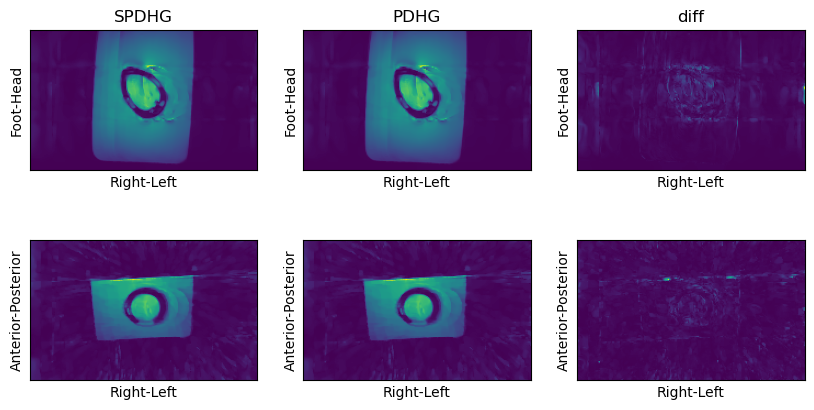

In [28]:
im = spdhg_2.get_output().as_array()

%matplotlib inline
# plot_rpe_3d([im],
#             [59, 64],
#             [f'SPDHG_{Nms}ms'],
#             [3*10**(-5)],
#             f'SPDHG_{Nms}ms.png')
plot_rpe_3d_simple([im, pdhg_2.solution.as_array(), im - pdhg_2.solution.as_array()], [64, 64]*3, ['SPDHG','PDHG', 'diff'])

In [29]:
pdhg_2_time.seconds/3600

1.1977777777777778

In [30]:
spdhg_2_time.seconds/3600

1.6202777777777777

In [31]:
print("That's all folks!")

That's all folks!


In [32]:
import timeit
import gc

class AvgMe:
    def __init__(self):
        self.reset()
        
    def reset(self):
        self.N = 0
        self.avg = 0
        self.var = 0
        self.min = 0
        self.max = 0
        self.r_sigma = -1
        self.skewness = 0
        self.kurtosis = 0
        
    def add_reading(self, val):
        if (self.N == 0):
            self.avg = val;
            self.min = val;
            self.max = val;
        elif (N == 1):
            # //set min/max
            self.max = val if val > self.max else self.max
            self.min = val if val < self.min else self.min        
                
            
            thisavg = (self.avg + val)/2;
            # initial value is in avg
            self.var = (self.avg - thisavg)*(self.avg - thisavg) + (val - self.thisavg) * (val - self.thisavg);
            self.skewness = self.var * (self.avg - thisavg);
            self.kurtosis = self.var * self.var;
            self.avg = thisavg;
        else:
            # set min/max
            self.max = val if val > self.max else self.max;
            self.min = val if val < self.min else self.min;        
            
            M = self.N
    
            # // b-factor =(<v>_N + v_(N+1)) / (N+1)
            b = (val - self.avg) / (M+1);
    
            self.kurtosis = self.kurtosis + (M *(b*b*b*b) * (1+M*M*M))- (4* b * self.skewness) + (6 * b *b * self.var * (M-1));
    
            self.skewness = self.skewness + (M * b*b*b *(M-1)*(M+1)) - (3 * b * self.var * (M-1));
    
            # //var = var * ((M-1)/M) + ((val - avg)*(val - avg)/(M+1)) ;
            self.var = self.var * ((M-1)/M) + (b * b * (M+1));
            
            self.avg = self.avg * (M/(M+1)) + val / (M+1);
        
        self.N += 1

In [33]:
ms = 1
import time
avgme = AvgMe()

N = 10

xxx = E_ms[ms].domain_geometry().allocate(0)
yyy = E_ms[ms].range_geometry().allocate(0)

tresults = {} 

for i in range(N):
    t0 = time.perf_counter()
    E_ms[ms].adjoint(acq_ms[ms], out=xxx)
    dt = time.perf_counter() - t0
    avgme.add_reading(dt)
    
print (f"{E_ms[ms].__class__.__name__} adjoint call took {avgme.avg:.3e} +- {np.sqrt(avgme.var):.3e} secs")

tresults[E_ms[ms].__class__.__name__] = {'adjoint': [avgme.avg, np.sqrt(avgme.var), N]}

# timer = timeit.Timer(stmt='E_ms[ms].adjoint(acq_ms[ms], out=xxx)', globals=globals())
# timer.repeat(2)

# %%timeit
avgme.reset()
for i in range(N):
    t0 = time.perf_counter()
    E_ms[ms].direct(xxx, out=yyy)
    dt = time.perf_counter() - t0
    avgme.add_reading(dt)
    
print (f"{E_ms[ms].__class__.__name__} direct call took {avgme.avg:.3e} +- {np.sqrt(avgme.var):.3e} secs")
tresults[E_ms[ms].__class__.__name__]['direct'] = [avgme.avg, np.sqrt(avgme.var), N]

MRAcquisitionModelWithNormCache adjoint call took 3.279e+00 +- 5.786e-02 secs
MRAcquisitionModelWithNormCache direct call took 3.029e+00 +- 7.278e-02 secs


In [34]:
xxx2 = xxx * 0
ms = 1
# %%timeit
avgme.reset()
for i in range(N):
    t0 = time.perf_counter()
    mf_resampler[ms].direct(xxx, out=xxx2)
    dt = time.perf_counter() - t0
    avgme.add_reading(dt)
    
print (f"{mf_resampler[ms].__class__.__name__} direct call took {avgme.avg:.3e} +- {np.sqrt(avgme.var):.3e} secs") 
tresults[mf_resampler[ms].__class__.__name__] = {'adjoint': [avgme.avg, np.sqrt(avgme.var), N]}

NiftyResampleWithNormCache direct call took 2.026e+00 +- 9.560e-02 secs


In [35]:
avgme.reset()
for i in range(N):
    t0 = time.perf_counter()
    mf_resampler[ms].adjoint(xxx, out=xxx2)
    dt = time.perf_counter() - t0
    avgme.add_reading(dt)
    
print (f"{mf_resampler[ms].__class__.__name__} adjoint call took {avgme.avg:.3e} +- {np.sqrt(avgme.var):.3e} secs") 
tresults[mf_resampler[ms].__class__.__name__]['direct'] = [avgme.avg, np.sqrt(avgme.var), N]
# %%timeit
# mf_resampler[ms].adjoint(xxx, out=xxx2)
# %%timeit

NiftyResampleWithNormCache adjoint call took 2.328e+00 +- 6.854e-02 secs


In [36]:
avgme.reset()
for i in range(N):
    t0 = time.perf_counter()
    C[ms].direct(xxx, out=yyy)
    dt = time.perf_counter() - t0
    avgme.add_reading(dt)
    
print (f"{C[ms].__class__.__name__} direct call took {avgme.avg:.3e} +- {np.sqrt(avgme.var):.3e} secs") 
# C[ms].direct(xxx, out=yyy)
# %%timeit
tresults[C[ms].__class__.__name__] = {'adjoint': [avgme.avg, np.sqrt(avgme.var), N]}

CompositionOperator direct call took 5.030e+00 +- 1.390e-01 secs


In [37]:
avgme.reset()
for i in range(N):
    t0 = time.perf_counter()
    C[ms].adjoint(yyy, out=xxx)
    dt = time.perf_counter() - t0
    avgme.add_reading(dt)
    
print (f"{C[ms].__class__.__name__} adjoint call took {avgme.avg:.3e} +- {np.sqrt(avgme.var):.3e} secs") 
tresults[C[ms].__class__.__name__]['direct'] = [avgme.avg, np.sqrt(avgme.var), N]

CompositionOperator adjoint call took 5.502e+00 +- 1.009e-01 secs


In [38]:
# C[ms].adjoint(yyy, out=xxx)
# %%timeit

avgme.reset()
for i in range(N):
    t0 = time.perf_counter()
    A.adjoint(acq_ms_block, out=x_init)
    dt = time.perf_counter() - t0
    avgme.add_reading(dt)
    
print (f"{A.__class__.__name__} adjoint call took {avgme.avg:.3e} +- {np.sqrt(avgme.var):.3e} secs") 
tresults[A.__class__.__name__] = {'adjoint': [avgme.avg, np.sqrt(avgme.var), N]}

BlockOperator adjoint call took 1.650e+01 +- 3.155e-01 secs


In [39]:
# A.adjoint(acq_ms_block, out=x_init)
yy = acq_ms_block * 0
# %%timeit
# A.direct(x_init, out=yy)


avgme.reset()
for i in range(N):
    t0 = time.perf_counter()
    A.direct(x_init, out=yy)
    dt = time.perf_counter() - t0
    avgme.add_reading(dt)
    
print (f"{A.__class__.__name__} direct call took {avgme.avg:.3e} +- {np.sqrt(avgme.var):.3e} secs") 
tresults[A.__class__.__name__]['direct'] = [avgme.avg, np.sqrt(avgme.var), N]

for k,v in tresults.items():
    print (k,v)
# print (tresults)

BlockOperator direct call took 1.597e+01 +- 4.582e-01 secs
MRAcquisitionModelWithNormCache {'adjoint': [3.279023800982395, 0.05785829398284727, 10], 'direct': [3.0294781562930435, 0.07278316463726713, 10]}
NiftyResampleWithNormCache {'adjoint': [2.025540794612607, 0.09560253542114205, 10], 'direct': [2.327557240606984, 0.06853980823144869, 10]}
CompositionOperator {'adjoint': [5.030387665494345, 0.1389753213700109, 10], 'direct': [5.502022841817234, 0.10092792643415435, 10]}
BlockOperator {'adjoint': [16.501497212308458, 0.31550646091193196, 10], 'direct': [15.965637777087975, 0.45820295965130936, 10]}


## The End

In [ ]:
print ("A.norm() {}\n".format(A.norm()))
whole_norm = 0
for el in A:
    print (f"Operator {el.__class__.__name__} norm: {el.norm()}")
    product_norm = reduce(lambda a,b: a * b, [aa.norm() for aa in el.operators], 1)
    print (f"- Product of norms: {product_norm}")
    whole_norm += (product_norm * product_norm)
    for a in el.operators:
        print (f"- Operator {a.__class__.__name__} norm: {a.norm()}")
    print("")
print(f"whole_norm: {np.sqrt(whole_norm)}")

In [ ]:
print ("A.norm() {}".format(A.norm()))
from functools import reduce
for el in A:
    print (f"Operator {el.__class__.__name__} norm: {el.norm()}")
    product_norm = reduce(lambda a,b: a * b, [aa.norm() for aa in el.operators], 1)
    print (f"Product of norms: {product_norm}")
    # for a in el.operators:
    #     print (f"Operator {a.__class__.__name__} norm: {a.norm()}")

In [ ]:
# FISTA 
from cil.optimisation.functions import LeastSquares

F_all_subs = []
norms = spdhg_2.norms

for i in range(len(acq_ms_block.containers)):
    fi = LeastSquares(A=C[i], b=acq_ms_block[i], c=omega)
    # Use pre computed A norm to calculate the Lipschitz constant
    # https://github.com/TomographicImaging/CIL/blob/2b3e2cd393c7ae15e27a7539c144c5197afbacef/Wrappers/Python/cil/optimisation/functions/LeastSquares.py#L135C13-L135C64
    fi.L = 2.0 * np.abs(fi.c) * (norms[i]**2)
    print (fi.L)
    F_all_subs.append(fi)

from cil.optimisation.functions import SumFunction
Fi = SumFunction(*F_all_subs)
x_init = C[i].domain_geometry().allocate( 0.0 )


In [42]:
fista_2 = FISTA(f=Fi, g=G, initial=x_init, max_iteration = n_epochs, 
            update_objective_interval = 1)


In [ ]:
sc = functools.partial(saveCallback, fista_2, f"FISTA_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
fista_2.run(15, verbose=2, callback=sc)

fista_2.update_objective_interval = 5 
fista_2.run(5, verbose=2, callback=sc)


fista_2.update_objective_interval = 10
fista_2.run(verbose=2, callback=sc)
end = datetime.now()
save_itrobj(fista_2, data_path, recons, Nms)

In [ ]:
im = fista_2.get_output().as_array()

%matplotlib inline
plot_rpe_3d([im],
            [59, 64],
            [f'FISTA, {Nms}ms'],
            [3*10**(-5)],
            f'FISTA, {Nms}ms.png')

38.123310470953584